# Notebook 01 — Data Audit & Profiling

## Purpose
This notebook performs the initial data audit and profiling for the **Los Angeles Traffic Collision Project**.

The purpose of this notebook is to understand the raw datasets before any cleaning, transformation, or modeling begins. This is a critical first step in any analytical workflow because reliable downstream analysis depends on a clear understanding of:
- dataset structure
- variable definitions
- missing values
- duplication risk
- temporal coverage
- categorical quality
- linkage readiness across source files

## Scientific / Methodological Basis
This notebook is aligned with recognized data science and analytics methodologies, especially:

- **CRISP-DM**: Data Understanding phase  
- **KDD Process**: data familiarization before preprocessing  
- **Data Quality Assessment principles**: completeness, consistency, uniqueness, validity, and interpretability

## Scope of This Notebook
In this notebook, we will:
1. Load the raw source files
2. Inspect structure and schema
3. Evaluate missing values
4. Check duplicates and key uniqueness
5. Assess date coverage
6. Review important categorical fields
7. Examine the raw MO Codes field
8. Assess the linkage potential with the classified MO Codes file
9. Produce audit outputs that will guide Notebook 02 (Data Cleaning)

## Expected Output
This notebook will produce:
- a documented baseline understanding of the raw data
- data quality summaries
- preliminary audit tables
- identified issues to be addressed in the cleaning phase

In [23]:
# ============================================================
# 1) Imports
# ============================================================
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

## Project Path Setup

To keep the project reproducible and portable across different machines, we will use **relative paths** rather than hard-coded local paths.

This follows good analytical engineering practice and supports:
- reproducibility
- portability
- easier collaboration
- reduced dependency on machine-specific folder structures

In this project, we assume:
- the notebook is stored inside the `notebooks` folder
- raw source files are stored inside `data/raw`
- audit outputs will be written to `outputs/tables/audit` and `outputs/figures/audit`

This setup will allow the notebook to run correctly as long as the project folder structure remains consistent.

In [24]:
# ============================================================
# 2) Project root and file paths
# ============================================================
CURRENT_DIR = Path.cwd()

# If the notebook is inside /notebooks, parent is the project root
if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables" / "audit"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "audit"

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COLLISIONS_FILE = RAW_DIR / "Traffic_Collision_Data_from_2010_to_Present_20260127.csv"
MO_CLASSIFIED_FILE = RAW_DIR / "MO_Codes_Classified_for_Traffic_Project.csv"

print("CURRENT_DIR   :", CURRENT_DIR)
print("PROJECT_ROOT  :", PROJECT_ROOT)
print("DATA_DIR      :", DATA_DIR)
print("RAW_DIR       :", RAW_DIR)
print("COLLISIONS    :", COLLISIONS_FILE)
print("MO_CLASSIFIED :", MO_CLASSIFIED_FILE)
print("TABLE OUTPUTS :", OUTPUT_TABLES_DIR)
print("FIG OUTPUTS   :", OUTPUT_FIGURES_DIR)

CURRENT_DIR   : c:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\notebooks
PROJECT_ROOT  : c:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project
DATA_DIR      : c:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\data
RAW_DIR       : c:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\data\raw
COLLISIONS    : c:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\data\raw\Traffic_Collision_Data_from_2010_to_Present_20260127.csv
MO_CLASSIFIED : c:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\data\raw\MO_Codes_Classified_for_Traffic_Project.csv
TABLE OUTPUTS : c:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\tables\audit
FIG OUTPUTS   : c:\Users\MKamal\Desktop\Project\without output\la_traffic_collision_project\outputs\figures\audit


## Source File Existence Validation

Before loading the raw datasets, it is good analytical practice to validate that the expected source files are physically present in the project structure.

This step improves notebook robustness and supports:
- early failure detection
- clearer debugging
- reproducibility
- safer execution across different machines and environments

Instead of allowing the notebook to fail later during file loading with a generic error, we explicitly verify that the required files exist in the expected locations.

This is especially important in structured analytical projects where:
- file names may change
- folders may be moved
- multiple project versions may coexist

If a required file is missing, the notebook should stop immediately with a clear and interpretable error message.

In [25]:
# ============================================================
# 2.1) Validate source file existence
# ============================================================
assert COLLISIONS_FILE.exists(), f"Missing collisions source file: {COLLISIONS_FILE}"
assert MO_CLASSIFIED_FILE.exists(), f"Missing classified MO file: {MO_CLASSIFIED_FILE}"

print("All required source files are available.")
print(" -", COLLISIONS_FILE.name)
print(" -", MO_CLASSIFIED_FILE.name)

All required source files are available.
 - Traffic_Collision_Data_from_2010_to_Present_20260127.csv
 - MO_Codes_Classified_for_Traffic_Project.csv


## Raw Data Loading

At this stage, we load the raw files **without modifying their content**.

This is important because the audit notebook should evaluate the data in its original state.  
Any transformations or corrections at this point would reduce the value of the audit and may hide real data quality issues that need to be documented.

We will load:
- the main collision dataset
- the classified MO code reference file

In [26]:
# ============================================================
# 3) Load raw datasets
# ============================================================
df_collisions = pd.read_csv(COLLISIONS_FILE, low_memory=False)
df_mo = pd.read_csv(MO_CLASSIFIED_FILE)

print("Collisions shape :", df_collisions.shape)
print("MO file shape    :", df_mo.shape)

Collisions shape : (621677, 18)
MO file shape    : (777, 21)


## First Look at the Data

The first inspection step is not meant to conclude anything final.  
Its role is to quickly observe:
- column names
- apparent field structure
- readability
- potential formatting issues
- whether the imported files match expectations

This is a standard exploratory audit step before moving into structured profiling.

In [27]:
# ============================================================
# 4) Preview data
# ============================================================
display(df_collisions.head(3))
display(df_mo.head(10))

,DR Number,Date Reported,Date Occurred,Time Occurred,Area ID,Area Name,Reporting District,Crime Code,Crime Code Description,MO Codes,Victim Age,Victim Sex,Victim Descent,Premise Code,Premise Description,Address,Cross Street,Location
0,212013850,09/03/2021,09/02/2021,2335,20,Olympic,2021,997,TRAFFIC COLLISION,3004 3027 3034 4027 3036 3101 3401 3701,25.0,F,W,101.0,STREET,WILTON PL,6TH ST,"(34.063, -118.3141)"
1,221417787,10/17/2022,10/17/2022,1620,14,Pacific,1406,997,TRAFFIC COLLISION,4027 3011 3028 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,NATIONAL BL,MOTOR AV,"(34.029, -118.4113)"
2,221418141,10/26/2022,10/26/2022,1135,14,Pacific,1434,997,TRAFFIC COLLISION,4027 3011 3025 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,PALMS BL,ROSEWOOD AV,"(34.0052, -118.4478)"


,Code,Code_Number,Description,Code_Family,Analytical_Domain,Analytical_Category,Analytical_Subcategory,Primary_Entity,Dashboard_Group,Traffic_Relevance_Score,Traffic_Relevance_Band,Keep_in_Main_Collision_Dashboard,Modeling_Role,Recommended_Use,Flag_Traffic_Core,Flag_Vehicle_or_RoadUser,Flag_Person_Profile,Flag_Location_Infrastructure,Flag_Behavior_Tactic,Flag_Severity_Harm,Flag_Jurisdiction_Admin
0,100,100,Suspect Impersonate,100s,Approach / Pretext,Approach Strategy,Identity / role impersonation,Suspect,Narrative enrichment,0,0 - Exclude,No,Exclude from main collision model,Exclude from the core collision mart and keep only in the raw-reference lookup.,0,0,1,0,1,0,0
1,101,101,Aid victim,100s,Approach / Pretext,Approach Strategy,Helpful / familiar-contact pretext,Suspect,Narrative enrichment,0,0 - Exclude,No,Exclude from main collision model,Exclude from the core collision mart and keep only in the raw-reference lookup.,0,0,1,0,1,0,0
2,102,102,Blind,100s,Approach / Pretext,Approach Strategy,Disability / sympathy pretext,Suspect,Narrative enrichment,0,0 - Exclude,No,Exclude from main collision model,Exclude from the core collision mart and keep only in the raw-reference lookup.,0,0,1,0,1,0,0
3,103,103,Crippled,100s,Approach / Pretext,Approach Strategy,Disability / sympathy pretext,Suspect,Narrative enrichment,0,0 - Exclude,No,Exclude from main collision model,Exclude from the core collision mart and keep only in the raw-reference lookup.,0,0,1,0,1,0,0
4,104,104,Customer,100s,Approach / Pretext,Approach Strategy,Identity / role impersonation,Suspect,Narrative enrichment,0,0 - Exclude,No,Exclude from main collision model,Exclude from the core collision mart and keep only in the raw-reference lookup.,0,0,1,0,1,0,0
5,105,105,Delivery,100s,Approach / Pretext,Approach Strategy,Authority / service-role pretext,Suspect,Narrative enrichment,0,0 - Exclude,No,Exclude from main collision model,Exclude from the core collision mart and keep only in the raw-reference lookup.,0,0,1,0,1,0,0
6,106,106,Doctor,100s,Approach / Pretext,Approach Strategy,Authority / service-role pretext,Suspect,Narrative enrichment,0,0 - Exclude,No,Exclude from main collision model,Exclude from the core collision mart and keep only in the raw-reference lookup.,0,0,1,0,1,0,0
7,107,107,God,100s,Approach / Pretext,Approach Strategy,Identity / role impersonation,Suspect,Narrative enrichment,0,0 - Exclude,No,Exclude from main collision model,Exclude from the core collision mart and keep only in the raw-reference lookup.,0,0,1,0,1,0,0
8,108,108,Infirm,100s,Approach / Pretext,Approach Strategy,Disability / sympathy pretext,Suspect,Narrative enrichment,0,0 - Exclude,No,Exclude from main collision model,Exclude from the core collision mart and keep only in the raw-reference lookup.,0,0,1,0,1,0,0
9,109,109,Inspector,100s,Approach / Pretext,Approach Strategy,Authority / service-role pretext,Suspect,Narrative enrichment,0,0 - Exclude,No,Exclude from main collision model,Exclude from the core collision mart and keep only in the raw-reference lookup.,0,0,1,0,1,0,0


## Schema Inspection

A schema review is essential for identifying:
- data types
- fields imported incorrectly
- potential date fields stored as text
- categorical fields that may require standardization later

This step supports one of the core data quality dimensions: **validity**.

In [28]:
# ============================================================
# 5) Schema review
# ============================================================
schema_collisions = pd.DataFrame({
    "column_name": df_collisions.columns,
    "dtype": df_collisions.dtypes.astype(str).values,
    "non_null_count": df_collisions.notna().sum().values,
    "null_count": df_collisions.isna().sum().values,
    "null_pct": (df_collisions.isna().mean().values * 100).round(2)
})

schema_mo = pd.DataFrame({
    "column_name": df_mo.columns,
    "dtype": df_mo.dtypes.astype(str).values,
    "non_null_count": df_mo.notna().sum().values,
    "null_count": df_mo.isna().sum().values,
    "null_pct": (df_mo.isna().mean().values * 100).round(2)
})

display(schema_collisions)
display(schema_mo)

schema_collisions.to_csv(OUTPUT_TABLES_DIR / "audit_schema_collisions.csv", index=False)
schema_mo.to_csv(OUTPUT_TABLES_DIR / "audit_schema_mo_file.csv", index=False)

,column_name,dtype,non_null_count,null_count,null_pct
0,DR Number,int64,621677,0,0.00
1,Date Reported,str,621677,0,0.00
2,Date Occurred,str,621677,0,0.00
3,Time Occurred,int64,621677,0,0.00
4,Area ID,int64,621677,0,0.00
5,Area Name,str,621677,0,0.00
6,Reporting District,int64,621677,0,0.00
7,Crime Code,int64,621677,0,0.00
8,Crime Code Description,str,621677,0,0.00
9,MO Codes,str,534353,87324,14.05


,column_name,dtype,non_null_count,null_count,null_pct
0,Code,int64,777,0,0.0
1,Code_Number,int64,777,0,0.0
2,Description,str,777,0,0.0
3,Code_Family,str,777,0,0.0
4,Analytical_Domain,str,777,0,0.0
5,Analytical_Category,str,777,0,0.0
6,Analytical_Subcategory,str,777,0,0.0
7,Primary_Entity,str,777,0,0.0
8,Dashboard_Group,str,777,0,0.0
9,Traffic_Relevance_Score,int64,777,0,0.0


## Structural Summary

Before moving to field-level audit, we need a concise structural summary:
- number of rows
- number of columns
- memory footprint
- number of unique rows if applicable

This gives us a high-level understanding of dataset scale and expected processing needs.

In [29]:
# ============================================================
# 6) Structural summary
# ============================================================
summary_structural = pd.DataFrame({
    "dataset_name": ["collisions_raw", "mo_classified"],
    "rows": [len(df_collisions), len(df_mo)],
    "columns": [df_collisions.shape[1], df_mo.shape[1]],
    "memory_mb": [
        round(df_collisions.memory_usage(deep=True).sum() / (1024**2), 2),
        round(df_mo.memory_usage(deep=True).sum() / (1024**2), 2)
    ]
})

display(summary_structural)
summary_structural.to_csv(OUTPUT_TABLES_DIR / "audit_shape_summary.csv", index=False)

,dataset_name,rows,columns,memory_mb
0,collisions_raw,621677,18,176.15
1,mo_classified,777,21,0.32


## Missing Value Assessment

Missing-value analysis is one of the first formal data quality checks.  
It helps assess **completeness**, which is a primary quality dimension in analytical projects.

At this stage, we are not imputing or correcting anything.  
We only measure:
- how much data is missing
- where the missingness is concentrated
- which fields may need rules or assumptions in the cleaning phase

In [30]:
# ============================================================
# 7) Missing values audit
# ============================================================
missing_summary = pd.DataFrame({
    "column_name": df_collisions.columns,
    "missing_count": df_collisions.isna().sum().values,
    "missing_pct": (df_collisions.isna().mean().values * 100).round(2)
}).sort_values(by="missing_pct", ascending=False).reset_index(drop=True)

display(missing_summary)
missing_summary.to_csv(OUTPUT_TABLES_DIR / "audit_missing_values_collisions.csv", index=False)

,column_name,missing_count,missing_pct
0,Victim Age,88194,14.19
1,MO Codes,87324,14.05
2,Cross Street,29460,4.74
3,Victim Descent,11648,1.87
4,Victim Sex,10697,1.72
5,Premise Code,959,0.15
6,Premise Description,960,0.15
7,DR Number,0,0.00
8,Date Reported,0,0.00
9,Date Occurred,0,0.00


## Key Uniqueness and Duplicate Check

A reliable analytical model depends on identifying whether a stable record key exists.

For the collision dataset, `DR Number` is expected to behave as a unique collision identifier.  
This step checks:
- whether duplicate rows exist
- whether the assumed key is unique
- whether a record-level fact table can be safely built later

This relates directly to the data quality dimension of **uniqueness**.

In [31]:
# ============================================================
# 8) Duplicate checks
# ============================================================
full_row_duplicates = df_collisions.duplicated().sum()

dr_col = "DR Number" if "DR Number" in df_collisions.columns else None

if dr_col:
    duplicate_dr_count = df_collisions.duplicated(subset=[dr_col]).sum()
    unique_dr_count = df_collisions[dr_col].nunique(dropna=True)
else:
    duplicate_dr_count = np.nan
    unique_dr_count = np.nan

duplicate_summary = pd.DataFrame({
    "metric": [
        "total_rows",
        "full_row_duplicates",
        "duplicate_dr_number_rows",
        "unique_dr_numbers"
    ],
    "value": [
        len(df_collisions),
        full_row_duplicates,
        duplicate_dr_count,
        unique_dr_count
    ]
})

display(duplicate_summary)
duplicate_summary.to_csv(OUTPUT_TABLES_DIR / "audit_duplicates_check.csv", index=False)

,metric,value
0,total_rows,621677
1,full_row_duplicates,0
2,duplicate_dr_number_rows,0
3,unique_dr_numbers,621677


## Column Name Standardization Preview

At the audit stage, we keep the raw data unchanged.  
However, it is useful to preview a standardized naming convention that will likely be used in the cleaning notebook.

This supports:
- code readability
- SQL compatibility
- BI tool consistency
- easier downstream transformations

This preview is informational only and does not yet alter the source dataframe.

In [32]:
# ============================================================
# 9) Preview standardized column names (informational)
# ============================================================
def standardize_column_name(col: str) -> str:
    col = col.strip().lower()
    col = col.replace("/", "_")
    col = col.replace("-", "_")
    col = col.replace("(", "")
    col = col.replace(")", "")
    col = col.replace(".", "")
    col = col.replace(",", "")
    col = col.replace("  ", " ")
    col = col.replace(" ", "_")
    return col

column_mapping_preview = pd.DataFrame({
    "raw_column_name": df_collisions.columns,
    "proposed_standard_name": [standardize_column_name(c) for c in df_collisions.columns]
})

display(column_mapping_preview)
column_mapping_preview.to_csv(OUTPUT_TABLES_DIR / "audit_column_mapping_preview.csv", index=False)

,raw_column_name,proposed_standard_name
0,DR Number,dr_number
1,Date Reported,date_reported
2,Date Occurred,date_occurred
3,Time Occurred,time_occurred
4,Area ID,area_id
5,Area Name,area_name
6,Reporting District,reporting_district
7,Crime Code,crime_code
8,Crime Code Description,crime_code_description
9,MO Codes,mo_codes


## Date Field Audit

Date fields define the temporal scope of the project and affect:
- trend analysis
- seasonality analysis
- period comparability
- dashboard filtering
- date dimension design

At the audit stage, our objective is to assess whether the raw date fields are broadly parseable and suitable for downstream analytical use.

This review focuses on:
- minimum and maximum available dates
- basic parsing success
- missing or malformed records
- overall temporal coverage at a high level

### Methodological Note
In this notebook, date parsing is performed as a **preliminary audit step** using tolerant parsing logic in order to measure field usability and detect obvious issues.

This is not the final production parsing approach.

In the dedicated cleaning notebook, date conversion should be implemented using a more explicit and controlled parsing strategy whenever the raw source format is confirmed. This improves:
- reproducibility
- parsing transparency
- consistency across environments
- protection against ambiguous date interpretation

At this stage, the purpose is diagnostic rather than transformational.

In [33]:
# ============================================================
# 10) Date parsing audit
# ============================================================
date_occ_col = "Date Occurred"
date_rpt_col = "Date Reported"

df_date_audit = df_collisions.copy()

df_date_audit["date_occurred_parsed"] = pd.to_datetime(
    df_date_audit[date_occ_col], errors="coerce"
) if date_occ_col in df_date_audit.columns else pd.NaT

df_date_audit["date_reported_parsed"] = pd.to_datetime(
    df_date_audit[date_rpt_col], errors="coerce"
) if date_rpt_col in df_date_audit.columns else pd.NaT

date_range_summary = pd.DataFrame({
    "field": ["date_occurred_parsed", "date_reported_parsed"],
    "min_date": [
        df_date_audit["date_occurred_parsed"].min(),
        df_date_audit["date_reported_parsed"].min()
    ],
    "max_date": [
        df_date_audit["date_occurred_parsed"].max(),
        df_date_audit["date_reported_parsed"].max()
    ],
    "null_count": [
        df_date_audit["date_occurred_parsed"].isna().sum(),
        df_date_audit["date_reported_parsed"].isna().sum()
    ]
})

display(date_range_summary)
date_range_summary.to_csv(OUTPUT_TABLES_DIR / "audit_date_range_summary.csv", index=False)

,field,min_date,max_date,null_count
0,date_occurred_parsed,2010-01-01,2025-03-08,0
1,date_reported_parsed,2010-01-01,2025-03-08,0


## Annual Record Distribution

A simple annual distribution helps detect:
- incomplete years
- structural breaks
- unusual drops or spikes
- possible extraction limitations

This does not yet explain why changes happened, but it highlights temporal patterns that must be interpreted carefully later.

In [34]:
# ============================================================
# 11) Annual volume audit
# ============================================================
df_date_audit["occur_year"] = df_date_audit["date_occurred_parsed"].dt.year

annual_counts = (
    df_date_audit["occur_year"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)
annual_counts.columns = ["year", "collision_count"]

display(annual_counts)
annual_counts.to_csv(OUTPUT_TABLES_DIR / "audit_annual_collision_counts.csv", index=False)

,year,collision_count
0,2010,45098
1,2011,45280
2,2012,45409
3,2013,45040
4,2014,46957
5,2015,52488
6,2016,56532
7,2017,57727
8,2018,57159
9,2019,56628


## Annual Collision Volume Visualization

A year-level volume chart provides a quick visual check of temporal coverage across the dataset.

This visualization is used here for **audit purposes only**.  
Its role is to highlight:
- possible incomplete years
- structural shifts in record volume
- unusual changes that may require validation before interpretation

### Important Interpretation Note
At the audit stage, changes in annual record counts should not automatically be interpreted as true changes in real-world collision incidence.

They may also reflect:
- incomplete extraction periods
- source-system changes
- reporting changes
- publication timing effects

For that reason, this chart should be treated as a **coverage diagnostic** rather than a finalized business insight.

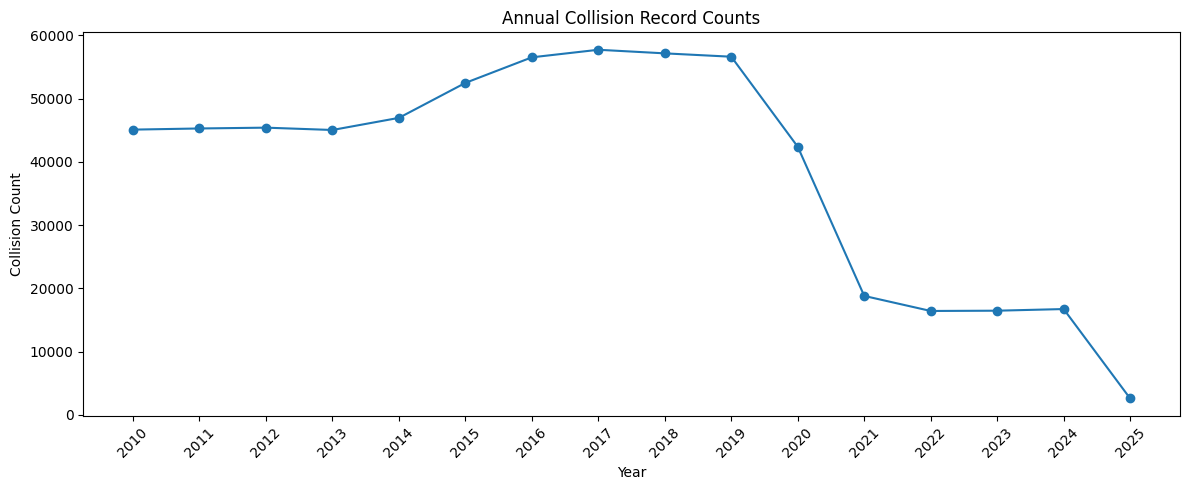

In [35]:
# ============================================================
# 11.1) Annual collision count chart
# ============================================================
import matplotlib.pyplot as plt

annual_counts_plot = annual_counts.dropna(subset=["year"]).copy()
annual_counts_plot["year"] = annual_counts_plot["year"].astype(int)

plt.figure(figsize=(12, 5))
plt.plot(annual_counts_plot["year"], annual_counts_plot["collision_count"], marker="o")
plt.title("Annual Collision Record Counts")
plt.xlabel("Year")
plt.ylabel("Collision Count")
plt.xticks(annual_counts_plot["year"], rotation=45)
plt.tight_layout()

plt.savefig(OUTPUT_FIGURES_DIR / "audit_annual_collision_counts.png", dpi=300, bbox_inches="tight")
plt.show()

## Time Field Audit

The time field is important for:
- hourly trend analysis
- daypart analysis
- operational patterns
- temporal risk windows

Raw time fields in public datasets often suffer from:
- inconsistent formatting
- missing leading zeros
- invalid hour values
- invalid minute values
- placeholder or malformed records

At this stage, we do not finalize the cleaned time logic. Instead, we perform an audit-stage inspection to understand the raw field and assess its readiness for standardization in the next notebook.

This review includes:
- basic field statistics
- sample raw values
- a preliminary validity check after zero-padding to a four-digit `HHMM` representation

This helps determine whether the field is broadly usable as-is, or whether special cleaning rules will be required before deriving the final hour-based analytical features.

In [36]:
# ============================================================
# 12) Raw time field inspection and preliminary validity audit
# ============================================================
time_col = "Time Occurred"

if time_col in df_collisions.columns:
    time_raw_series = df_collisions[time_col].copy()

    # Basic descriptive audit
    sample_raw_time_values = (
        time_raw_series
        .dropna()
        .astype(str)
        .head(20)
        .tolist()
    )

    raw_time_stats = pd.DataFrame({
        "metric": [
            "total_rows",
            "non_null_count",
            "null_count",
            "unique_count"
        ],
        "value": [
            len(time_raw_series),
            time_raw_series.notna().sum(),
            time_raw_series.isna().sum(),
            time_raw_series.nunique(dropna=True)
        ]
    })

    # Preliminary validity audit
    time_numeric = pd.to_numeric(time_raw_series, errors="coerce")

    time_hhmm_str = (
        time_numeric
        .dropna()
        .astype(int)
        .astype(str)
        .str.zfill(4)
    )

    time_validity_df = pd.DataFrame({"hhmm": time_hhmm_str})
    time_validity_df["hour"] = pd.to_numeric(time_validity_df["hhmm"].str[:2], errors="coerce")
    time_validity_df["minute"] = pd.to_numeric(time_validity_df["hhmm"].str[2:], errors="coerce")

    valid_hour_mask = time_validity_df["hour"].between(0, 23, inclusive="both")
    valid_minute_mask = time_validity_df["minute"].between(0, 59, inclusive="both")
    valid_time_mask = valid_hour_mask & valid_minute_mask

    time_validity_summary = pd.DataFrame({
        "metric": [
            "numeric_parsable_rows",
            "non_numeric_rows",
            "valid_hhmm_rows",
            "invalid_hhmm_rows",
            "valid_hhmm_pct",
            "invalid_hhmm_pct"
        ],
        "value": [
            time_numeric.notna().sum(),
            time_numeric.isna().sum(),
            valid_time_mask.sum(),
            (~valid_time_mask).sum(),
            round(valid_time_mask.mean() * 100, 2) if len(time_validity_df) > 0 else np.nan,
            round((~valid_time_mask).mean() * 100, 2) if len(time_validity_df) > 0 else np.nan
        ]
    })

    time_summary = pd.DataFrame({
        "sample_raw_time_values": sample_raw_time_values
    })

    invalid_time_examples = (
        time_validity_df.loc[~valid_time_mask, ["hhmm", "hour", "minute"]]
        .head(25)
        .reset_index(drop=True)
    )

    display(raw_time_stats)
    display(time_summary)
    display(time_validity_summary)

    if len(invalid_time_examples) > 0:
        display(invalid_time_examples)
    else:
        print("No invalid HHMM time values were identified in the preliminary audit.")

    raw_time_stats.to_csv(OUTPUT_TABLES_DIR / "audit_time_field_stats.csv", index=False)
    time_validity_summary.to_csv(OUTPUT_TABLES_DIR / "audit_time_validity_summary.csv", index=False)
    invalid_time_examples.to_csv(OUTPUT_TABLES_DIR / "audit_invalid_time_examples.csv", index=False)

,metric,value
0,total_rows,621677
1,non_null_count,621677
2,null_count,0
3,unique_count,1439


,sample_raw_time_values
0,2335
1,1620
2,1135
3,230
4,450
5,2320
6,545
7,350
8,2100
9,950


,metric,value
0,numeric_parsable_rows,621677.0
1,non_numeric_rows,0.0
2,valid_hhmm_rows,621677.0
3,invalid_hhmm_rows,0.0
4,valid_hhmm_pct,100.0
5,invalid_hhmm_pct,0.0


No invalid HHMM time values were identified in the preliminary audit.


## Geographic Coordinate Audit

Latitude and longitude are critical for any geospatial analysis.  
However, location fields often contain:
- nulls
- zeros
- invalid coordinates
- points outside valid geographic ranges

This step evaluates coordinate validity to determine whether the dataset is suitable for mapping and hotspot analysis.

In [37]:
# ============================================================
# 13) Coordinate validity audit
# ============================================================
lat_col = "LAT"
lon_col = "LON"

coord_audit = pd.DataFrame()

if lat_col in df_collisions.columns and lon_col in df_collisions.columns:
    coord_audit = pd.DataFrame({
        "metric": [
            "lat_null_count",
            "lon_null_count",
            "lat_zero_count",
            "lon_zero_count",
            "both_zero_count",
            "lat_out_of_range_count",
            "lon_out_of_range_count"
        ],
        "value": [
            df_collisions[lat_col].isna().sum(),
            df_collisions[lon_col].isna().sum(),
            (df_collisions[lat_col] == 0).sum(),
            (df_collisions[lon_col] == 0).sum(),
            ((df_collisions[lat_col] == 0) & (df_collisions[lon_col] == 0)).sum(),
            ((df_collisions[lat_col] < -90) | (df_collisions[lat_col] > 90)).sum(),
            ((df_collisions[lon_col] < -180) | (df_collisions[lon_col] > 180)).sum(),
        ]
    })

display(coord_audit)
coord_audit.to_csv(OUTPUT_TABLES_DIR / "audit_invalid_coordinates.csv", index=False)

""


## Categorical Field Audit

Important categorical fields should be reviewed for:
- cardinality
- missing values
- suspicious labels
- standardization needs

In this notebook, we focus on high-value business fields such as:
- Area Name
- Reporting District
- Victim Sex
- Victim Descent
- Premise Description

This step helps define cleaning priorities and dashboard usability.

In [38]:
# ============================================================
# 14) Selected categorical fields audit
# ============================================================
candidate_cols = [
    "Area Name",
    "Rpt Dist No",
    "Victim Sex",
    "Victim Descent",
    "Premise Description"
]

cat_audit_rows = []

for col in candidate_cols:
    if col in df_collisions.columns:
        cat_audit_rows.append({
            "column_name": col,
            "non_null_count": df_collisions[col].notna().sum(),
            "null_count": df_collisions[col].isna().sum(),
            "null_pct": round(df_collisions[col].isna().mean() * 100, 2),
            "unique_count": df_collisions[col].nunique(dropna=True)
        })

categorical_audit = pd.DataFrame(cat_audit_rows)
display(categorical_audit)
categorical_audit.to_csv(OUTPUT_TABLES_DIR / "audit_selected_categorical_fields.csv", index=False)

,column_name,non_null_count,null_count,null_pct,unique_count
0,Area Name,621677,0,0.00,21
1,Victim Sex,610980,10697,1.72,6
2,Victim Descent,610029,11648,1.87,20
3,Premise Description,620717,960,0.15,124


## Victim Age Audit

Victim age is one of the most analytically valuable fields in the collision dataset because it supports:
- demographic profiling
- age-band analysis
- vulnerable road user assessment
- segmentation for downstream dashboards and summaries

However, age fields in operational and public datasets may contain:
- missing values
- zeros used as placeholders
- negative values
- unusually high values
- data-entry anomalies

At this stage, the purpose of the age audit is to perform a **screening-level quality review** rather than to enforce final cleaning rules.

This review helps identify:
- whether the field is broadly usable
- whether placeholder values may exist
- whether outlier handling rules may be needed in the cleaning phase

### Methodological Note
Thresholds such as very high age values are used here as **audit indicators** to flag potentially unusual observations.  
They should not be interpreted at this stage as automatic exclusion rules.

Final treatment decisions, including whether to retain, recode, or filter certain age values, will be defined later in the dedicated cleaning notebook based on analytical purpose and data-quality evidence.

In [39]:
# ============================================================
# 15) Victim age audit
# ============================================================
age_col = "Victim Age"

if age_col in df_collisions.columns:
    age_series = pd.to_numeric(df_collisions[age_col], errors="coerce")
    
    age_audit = pd.DataFrame({
        "metric": [
            "non_null_count",
            "null_count",
            "zero_count",
            "negative_count",
            "age_gt_100_count",
            "min_value",
            "max_value",
            "mean_value"
        ],
        "value": [
            age_series.notna().sum(),
            age_series.isna().sum(),
            (age_series == 0).sum(),
            (age_series < 0).sum(),
            (age_series > 100).sum(),
            age_series.min(),
            age_series.max(),
            round(age_series.mean(), 2)
        ]
    })

    display(age_audit)
    age_audit.to_csv(OUTPUT_TABLES_DIR / "audit_victim_age_summary.csv", index=False)

,metric,value
0,non_null_count,533483.0
1,null_count,88194.0
2,zero_count,0.0
3,negative_count,0.0
4,age_gt_100_count,0.0
5,min_value,10.0
6,max_value,99.0
7,mean_value,41.4


## MO Codes Field Audit

The MO Codes field is one of the most important fields in this project because it carries a large part of the analytical meaning behind each collision.

However, in raw form it presents several challenges:
- multiple codes may exist in one field
- spacing may be inconsistent
- some records may have no codes
- direct analysis is not possible without splitting and normalization

This step evaluates the raw state of the MO Codes column before formal transformation in Notebook 03.

In [40]:
# ============================================================
# 16) Raw MO Codes audit
# ============================================================
mo_col = "MO Codes"

if mo_col in df_collisions.columns:
    mo_raw = df_collisions[mo_col].astype(str).str.strip()
    mo_missing_mask = df_collisions[mo_col].isna() | (mo_raw == "") | (mo_raw.str.lower() == "nan")
    
    mo_audit = pd.DataFrame({
        "metric": [
            "total_rows",
            "rows_with_missing_mo_codes",
            "rows_with_non_missing_mo_codes"
        ],
        "value": [
            len(df_collisions),
            mo_missing_mask.sum(),
            (~mo_missing_mask).sum()
        ]
    })
    
    display(mo_audit)
    mo_audit.to_csv(OUTPUT_TABLES_DIR / "audit_mo_raw_presence.csv", index=False)

,metric,value
0,total_rows,621677
1,rows_with_missing_mo_codes,87324
2,rows_with_non_missing_mo_codes,534353


## MO Code Explosion Preview

The raw `MO Codes` field is one of the most analytically important fields in this project because it contains a large part of the contextual meaning behind each collision record. However, in its original form, it is not directly suitable for structured analysis because multiple codes may exist within the same field.

Before building the final collision-to-code bridge table in a later notebook, we need an audit-stage preview of what MO code normalization will produce.

In this step, we will:
- split the raw `MO Codes` string
- reshape it into row-level code relationships
- estimate the expected bridge-table volume
- inspect the number of codes per collision
- review code frequency at a preliminary level

### Parsing Assumption
For the current source file, this audit preview assumes that individual MO codes are separated by **whitespace** characters. This assumption is used here only for preliminary profiling and volume estimation.

### Why this step matters
This preview is essential because it informs:
- data model design
- SQL bridge-table expectations
- downstream dashboard strategy
- MO linkage readiness with the classified reference file

### Methodological Note
At this stage, the objective is not to finalize the MO transformation logic, but to:
- estimate row expansion impact
- evaluate normalization feasibility
- assess readiness for formal MO engineering in a later notebook

The parsing rule and normalization approach will be formally revalidated in the dedicated MO engineering notebook before production outputs are generated.

In [41]:
# ============================================================
# 17) MO explode preview
# ============================================================
if dr_col and mo_col in df_collisions.columns:
    df_mo_preview = df_collisions[[dr_col, mo_col]].copy()
    df_mo_preview[mo_col] = df_mo_preview[mo_col].fillna("").astype(str).str.strip()
    df_mo_preview = df_mo_preview[df_mo_preview[mo_col] != ""].copy()

    df_mo_preview["mo_code_list"] = df_mo_preview[mo_col].str.split()
    df_mo_preview["mo_code_count_per_collision"] = df_mo_preview["mo_code_list"].apply(len)

    mo_count_distribution = (
        df_mo_preview["mo_code_count_per_collision"]
        .value_counts()
        .sort_index()
        .reset_index()
    )
    mo_count_distribution.columns = ["mo_codes_per_collision", "collision_count"]

    df_mo_exploded_preview = df_mo_preview[[dr_col, "mo_code_list"]].explode("mo_code_list")
    df_mo_exploded_preview = df_mo_exploded_preview.rename(columns={"mo_code_list": "mo_code"})
    df_mo_exploded_preview["mo_code"] = df_mo_exploded_preview["mo_code"].astype(str).str.strip()

    mo_preview_summary = pd.DataFrame({
        "metric": [
            "collisions_with_mo_codes",
            "exploded_mo_rows",
            "unique_mo_codes_in_collision_file",
            "avg_codes_per_collision",
            "max_codes_per_collision"
        ],
        "value": [
            df_mo_preview[dr_col].nunique(),
            len(df_mo_exploded_preview),
            df_mo_exploded_preview["mo_code"].nunique(),
            round(df_mo_preview["mo_code_count_per_collision"].mean(), 2),
            df_mo_preview["mo_code_count_per_collision"].max()
        ]
    })

    display(mo_preview_summary)
    display(mo_count_distribution)

    mo_preview_summary.to_csv(OUTPUT_TABLES_DIR / "audit_mo_explode_preview_summary.csv", index=False)
    mo_count_distribution.to_csv(OUTPUT_TABLES_DIR / "audit_mo_code_count_distribution.csv", index=False)

,metric,value
0,collisions_with_mo_codes,534353.00
1,exploded_mo_rows,3523096.00
2,unique_mo_codes_in_collision_file,346.00
3,avg_codes_per_collision,6.59
4,max_codes_per_collision,10.00


,mo_codes_per_collision,collision_count
0,1,24470
1,2,5072
2,3,10179
3,4,23801
4,5,76553
5,6,98184
6,7,87068
7,8,117486
8,9,73892
9,10,17648


## MO Classification Linkage Audit

A key objective of the project is to connect raw collision MO codes to the project-specific classified MO file.

This linkage audit checks:
- how many exploded collision MO codes successfully map to the classified reference
- how many remain unmapped
- whether the classification layer is sufficient for analytical use

This is a critical readiness check before we build the dimensional model.

In [42]:
# ============================================================
# 18) MO mapping coverage audit
# ============================================================
# try to identify the code column in the classified file
possible_code_cols = ["Code", "MO Code", "MO_Code", "mo_code"]
classified_code_col = None

for c in possible_code_cols:
    if c in df_mo.columns:
        classified_code_col = c
        break

if classified_code_col is None:
    raise ValueError("Could not identify the MO code column in the classified MO file.")

df_mo_ref = df_mo.copy()
df_mo_ref["mo_code"] = df_mo_ref[classified_code_col].astype(str).str.strip()

mapping_check = df_mo_exploded_preview.merge(
    df_mo_ref[["mo_code"]].drop_duplicates(),
    on="mo_code",
    how="left",
    indicator=True
)

mapping_summary = pd.DataFrame({
    "metric": [
        "total_exploded_rows",
        "mapped_rows",
        "unmapped_rows",
        "mapped_pct",
        "unmapped_pct",
        "unique_collision_mo_codes",
        "unique_reference_mo_codes"
    ],
    "value": [
        len(mapping_check),
        (mapping_check["_merge"] == "both").sum(),
        (mapping_check["_merge"] == "left_only").sum(),
        round(((mapping_check["_merge"] == "both").mean() * 100), 2),
        round(((mapping_check["_merge"] == "left_only").mean() * 100), 2),
        df_mo_exploded_preview["mo_code"].nunique(),
        df_mo_ref["mo_code"].nunique()
    ]
})

unmapped_codes = (
    mapping_check.loc[mapping_check["_merge"] == "left_only", "mo_code"]
    .value_counts()
    .reset_index()
)
unmapped_codes.columns = ["mo_code", "unmapped_frequency"]

display(mapping_summary)
display(unmapped_codes.head(25))

mapping_summary.to_csv(OUTPUT_TABLES_DIR / "audit_mo_mapping_coverage_summary.csv", index=False)
unmapped_codes.to_csv(OUTPUT_TABLES_DIR / "audit_mo_unmapped_codes.csv", index=False)

,metric,value
0,total_exploded_rows,3523096.00
1,mapped_rows,3432744.00
2,unmapped_rows,90352.00
3,mapped_pct,97.44
4,unmapped_pct,2.56
5,unique_collision_mo_codes,346.00
6,unique_reference_mo_codes,777.00


,mo_code,unmapped_frequency
0,0605,83772
1,0110,1476
2,0947,1103
3,0101,964
4,0506,952
5,3064,307
6,0910,273
7,0907,175
8,0906,139
9,3063,116


## Dominant Collision Field Review

At the audit stage, it is useful to inspect whether some supposedly analytical fields are actually constant or near-constant.

If a field contains only one value across the dataset, it may still be useful as documentation, but it does not contribute meaningful analytical segmentation.

This helps prevent weak dashboard design and unnecessary model complexity.

In [43]:
# ============================================================
# 19) Constant / near-constant field check for major identifiers
# ============================================================
review_cols = ["Crime Code", "Crime Code Description"]

constant_field_rows = []

for col in review_cols:
    if col in df_collisions.columns:
        vc = df_collisions[col].value_counts(dropna=False)
        top_value = vc.index[0] if len(vc) > 0 else None
        top_count = vc.iloc[0] if len(vc) > 0 else None
        
        constant_field_rows.append({
            "column_name": col,
            "unique_count": df_collisions[col].nunique(dropna=True),
            "top_value": top_value,
            "top_value_count": top_count,
            "top_value_pct": round((top_count / len(df_collisions)) * 100, 2) if top_count is not None else np.nan
        })

constant_field_summary = pd.DataFrame(constant_field_rows)
display(constant_field_summary)
constant_field_summary.to_csv(OUTPUT_TABLES_DIR / "audit_constant_field_review.csv", index=False)

,column_name,unique_count,top_value,top_value_count,top_value_pct
0,Crime Code,1,997,621677,100.0
1,Crime Code Description,1,TRAFFIC COLLISION,621677,100.0


## Audit Findings Consolidation

At the end of the audit notebook, it is good practice to consolidate the key findings into a compact issue log.

This issue log is not the final cleaning plan, but it provides a structured handoff into the next notebook:
**Notebook 02 — Data Cleaning and Standardization**.

In [44]:
# ============================================================
# 20) Consolidated audit issue log
# ============================================================
issue_log = pd.DataFrame([
    {
        "issue_area": "missing_values",
        "issue_description": "Some analytical fields contain non-trivial missing values and require cleaning rules or explicit retention strategy.",
        "next_step": "Review field-by-field treatment in Notebook 02."
    },
    {
        "issue_area": "date_fields",
        "issue_description": "Date fields require standardized parsing and validation before deriving time-based analytics.",
        "next_step": "Parse and create time dimensions in Notebook 02."
    },
    {
        "issue_area": "temporal_completeness",
        "issue_description": "Year-level record volumes may reflect incomplete temporal coverage, especially in recent periods, and should not be interpreted as trend evidence without completeness validation.",
        "next_step": "Assess year and month coverage before finalizing trend interpretation."
    },
    {
        "issue_area": "time_field",
        "issue_description": "Raw time values appear structurally valid after preliminary HHMM normalization and are suitable for formal time derivation in the cleaning phase.",
        "next_step": "Standardize time formatting and derive hour field."
    },
    {
        "issue_area": "coordinates",
        "issue_description": "Invalid or zero coordinates may affect geospatial analysis.",
        "next_step": "Flag or remove invalid coordinates for mapping use cases."
    },
    {
        "issue_area": "mo_codes",
        "issue_description": "MO Codes are multi-valued and cannot be analyzed in raw form.",
        "next_step": "Explode MO Codes and build bridge table in Notebook 03."
    },
    {
        "issue_area": "mo_mapping",
        "issue_description": "MO classification coverage must be formally validated and unmapped codes reviewed.",
        "next_step": "Finalize classified linkage and QA review."
    },
    {
        "issue_area": "data_model_readiness",
        "issue_description": "The dataset appears suitable for fact + bridge + dimension modeling.",
        "next_step": "Prepare modeling-ready outputs after cleaning."
    }
])

display(issue_log)
issue_log.to_csv(OUTPUT_TABLES_DIR / "audit_issue_log.csv", index=False)

,issue_area,issue_description,next_step
0,missing_values,Some analytical fields contain non-trivial missing values and require cleaning rules or explicit retention strategy.,Review field-by-field treatment in Notebook 02.
1,date_fields,Date fields require standardized parsing and validation before deriving time-based analytics.,Parse and create time dimensions in Notebook 02.
2,temporal_completeness,"Year-level record volumes may reflect incomplete temporal coverage, especially in recent periods, and should not be ...",Assess year and month coverage before finalizing trend interpretation.
3,time_field,Raw time values appear structurally valid after preliminary HHMM normalization and are suitable for formal time deri...,Standardize time formatting and derive hour field.
4,coordinates,Invalid or zero coordinates may affect geospatial analysis.,Flag or remove invalid coordinates for mapping use cases.
5,mo_codes,MO Codes are multi-valued and cannot be analyzed in raw form.,Explode MO Codes and build bridge table in Notebook 03.
6,mo_mapping,MO classification coverage must be formally validated and unmapped codes reviewed.,Finalize classified linkage and QA review.
7,data_model_readiness,The dataset appears suitable for fact + bridge + dimension modeling.,Prepare modeling-ready outputs after cleaning.


# Notebook 01 Conclusion

This notebook established the raw-data baseline for the project through a structured audit of the two main source files:
- the collision dataset with **621,677 rows and 18 columns**
- the classified MO reference file with **777 rows** :contentReference[oaicite:0]{index=0}

## What has been completed

The notebook successfully completed the initial audit and profiling of the raw data and produced a documented baseline for the next project phase.

Key outcomes from this notebook include:

- the raw source files were loaded successfully and validated for existence before processing
- the project structure and audit output folders were configured successfully
- the collision dataset was confirmed to contain **621,677 raw records**
- the raw data structure was reviewed across **18 source columns**
- the classified MO reference file was loaded successfully with **777 reference records** :contentReference[oaicite:1]{index=1}

- date coverage was audited and annual record distribution was reviewed visually
- the annual trend highlighted a **temporal completeness risk**, especially in recent years, meaning that year-level volume changes should not be interpreted as final trend evidence before completeness validation
- this issue was formally documented in the audit issue log 

- the `Time Occurred` field showed strong initial quality:
  - **621,677 total rows**
  - **621,677 non-null values**
  - **0 null values**
  - **1,439 unique raw time values**
  - **621,677 numeric-parsable rows**
  - **621,677 valid HHMM rows**
  - **0 invalid HHMM rows**
  - **100.0% preliminary time validity**

- the `Victim Age` field also appeared analytically usable at the audit stage:
  - **533,483 non-null values**
  - **88,194 null values**
  - **0 zero values**
  - **0 negative values**
  - **0 values above 100**
  - minimum age = **10**
  - maximum age = **99**
  - mean age = **41.4**

- the raw `MO Codes` field was confirmed to be a critical analytical field, but not directly usable in its original format because it is multi-valued and requires normalization
- an exploded preview of the MO field was performed to estimate the structure of the future bridge table
- linkage readiness with the classified MO file was assessed as a key prerequisite before dimensional modeling
- the notebook confirmed that the dataset appears suitable for a downstream analytical model based on:
  - `fact_collisions`
  - `bridge_collision_mo`
  - `dim_mo_codes` 

## Main audit conclusions

Based on the results of Notebook 01, the following conclusions were reached:

- the raw collision dataset is suitable to serve as the project’s analytical starting point
- the time field is highly reliable and can be standardized confidently in the cleaning phase
- the age field is usable, but missing values must be handled explicitly
- MO Codes represent a major analytical enrichment layer and must be engineered separately
- temporal coverage must be treated carefully, especially for recent years
- the data is structurally ready to move into formal cleaning and standardization
- the audit phase successfully identified the main quality risks and transformation priorities for the project 

## What comes next

The next notebook will focus on:

**Notebook 02 — Data Cleaning & Standardization**

That notebook will convert the raw collision data into a trusted analytical base suitable for:
- exploratory analysis
- SQL modeling
- Excel aggregation
- Tableau outputs
- Power BI outputs

In practical terms, the next phase will focus on:
- standardizing column names
- parsing and validating date fields
- standardizing the time field and deriving hour-based features
- cleaning important categorical and demographic fields
- preparing a cleaned collision table for downstream modeling and dashboard development :contentReference[oaicite:5]{index=5}